# COVID-19新規陽性者数：外生変数候補の前処理確認

中間発表向けの実験ノートとして、厚生労働省の新規陽性者数（日別）raw CSVを読み込み、全国値の確認、月次化、外生変数候補の作成方法を確認する。
本ノートでは状態空間モデルの推定、モデル比較、再予測は行わない。

## 入力と前処理方針

- 入力：`data/experimental/covid_cases/raw/newly_confirmed_cases_daily.csv`（厚生労働省公式CSV）
- `Date`を日付型に変換し、`ALL`を全国新規陽性者数として扱う。
- `ALL`と47都道府県列の合計を日次で照合する。
- 日次`ALL`を暦月ごとに合計し、COVID外生変数の対象期間を2020年3月から2023年5月とする。
- 対象期間外は外生変数を0とし、`log1p_cases`、同変数のラグ0・ラグ1を作成する。

### 2023年5月8日の扱い

raw CSVには`2023/5/8`のレコードが含まれる。厚生労働省の案内は2023年5月7日分を最終集計値としているため、日付の意味（公表日との対応）には留保が必要である。本ノートでは、取得したraw値を削除せず、2023年5月の月次合計に含める。その扱いは、後続の分析で必要に応じて見直す。

In [1]:
from pathlib import Path
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ノートブックをプロジェクトルート／notebooks/experimentalのいずれから実行しても動くようにする。
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
for candidate in candidates:
    if (candidate / 'data/experimental/covid_cases/raw/newly_confirmed_cases_daily.csv').exists():
        PROJECT_ROOT = candidate.resolve()
        break
else:
    raise FileNotFoundError('プロジェクトルートまたはraw CSVを確認できない')

RAW_PATH = PROJECT_ROOT / 'data/experimental/covid_cases/raw/newly_confirmed_cases_daily.csv'
PROCESSED_PATH = PROJECT_ROOT / 'data/experimental/covid_cases/processed/monthly_cases.csv'
LOG_PATH = PROJECT_ROOT / 'output/covid_cases_exog/logs/preprocessing_log.md'
FIG_PATH = PROJECT_ROOT / 'output/covid_cases_exog/figures/monthly_cases_series.png'
ACQUISITION_LOG_PATH = PROJECT_ROOT / 'output/covid_cases_exog/logs/data_acquisition_log.md'

raw = pd.read_csv(RAW_PATH, encoding='utf-8-sig')
raw_csv_columns = raw.columns.tolist()
raw['Date'] = pd.to_datetime(raw['Date'], format='%Y/%m/%d', errors='raise')
display(raw.head(3))
print(f'入力: {RAW_PATH}')
print(f'行数={len(raw):,}, 列数={raw.shape[1]}')

,Date,ALL,Hokkaido,Aomori,Iwate,Miyagi,Akita,Yamagata,Fukushima,Ibaraki,...,Ehime,Kochi,Fukuoka,Saga,Nagasaki,Kumamoto,Oita,Miyazaki,Kagoshima,Okinawa
0,2020-01-16,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2020-01-17,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2020-01-18,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


入力: C:\Users\fugat\Desktop\python_project\Transport_amount_project\data\experimental\covid_cases\raw\newly_confirmed_cases_daily.csv
行数=1,209, 列数=49


In [2]:
# 全国値と都道府県合計の確認
prefecture_columns = [c for c in raw.columns if c not in {'Date', 'ALL'}]
assert len(prefecture_columns) == 47, f'都道府県列数={len(prefecture_columns)}'
numeric = raw[['ALL', *prefecture_columns]].apply(pd.to_numeric, errors='raise')
raw['prefecture_total'] = numeric[prefecture_columns].sum(axis=1)
raw['all_minus_prefecture_total'] = numeric['ALL'] - raw['prefecture_total']

difference_summary = pd.DataFrame({
    '項目': ['都道府県列数', '差分非ゼロ日数', '差分最小', '差分最大', '差分絶対値合計'],
    '値': [
        len(prefecture_columns),
        int((raw['all_minus_prefecture_total'] != 0).sum()),
        int(raw['all_minus_prefecture_total'].min()),
        int(raw['all_minus_prefecture_total'].max()),
        int(raw['all_minus_prefecture_total'].abs().sum()),
    ],
})
display(difference_summary)
print('都道府県列:', ', '.join(prefecture_columns))

,項目,値
0,都道府県列数,47
1,差分非ゼロ日数,0
2,差分最小,0
3,差分最大,0
4,差分絶対値合計,0


都道府県列: Hokkaido, Aomori, Iwate, Miyagi, Akita, Yamagata, Fukushima, Ibaraki, Tochigi, Gunma, Saitama, Chiba, Tokyo, Kanagawa, Niigata, Toyama, Ishikawa, Fukui, Yamanashi, Nagano, Gifu, Shizuoka, Aichi, Mie, Shiga, Kyoto, Osaka, Hyogo, Nara, Wakayama, Tottori, Shimane, Okayama, Hiroshima, Yamaguchi, Tokushima, Kagawa, Ehime, Kochi, Fukuoka, Saga, Nagasaki, Kumamoto, Oita, Miyazaki, Kagoshima, Okinawa


In [3]:
# 日付範囲、重複、欠落の確認
date_index = pd.DatetimeIndex(raw['Date'])
expected_dates = pd.date_range(date_index.min(), date_index.max(), freq='D')
missing_dates = expected_dates.difference(date_index)
duplicate_dates = int(date_index.duplicated().sum())
date_summary = pd.DataFrame({
    '項目': ['最小日付', '最大日付', '日付行数', 'ユニーク日数', '重複日付行数', '欠落日数'],
    '値': [
        date_index.min().strftime('%Y-%m-%d'),
        date_index.max().strftime('%Y-%m-%d'),
        len(date_index),
        date_index.nunique(),
        duplicate_dates,
        len(missing_dates),
    ],
})
display(date_summary)
if len(missing_dates):
    print('欠落日（先頭）:', list(missing_dates[:10]))

,項目,値
0,最小日付,2020-01-16
1,最大日付,2023-05-08
2,日付行数,1209
3,ユニーク日数,1209
4,重複日付行数,0
5,欠落日数,0


In [4]:
# 日次ALLを暦月合計へ変換し、外生変数候補を作成
daily = raw[['Date', 'ALL', 'prefecture_total']].copy()
daily['month'] = daily['Date'].dt.to_period('M').astype(str)
monthly = (
    daily.groupby('month', as_index=False)
    .agg(
        monthly_cases_all=('ALL', 'sum'),
        monthly_prefecture_total=('prefecture_total', 'sum'),
        daily_rows=('Date', 'size'),
        last_daily_date=('Date', 'max'),
    )
)
monthly['all_minus_prefecture_total'] = (
    monthly['monthly_cases_all'] - monthly['monthly_prefecture_total']
)
monthly['covid_period'] = monthly['month'].between('2020-03', '2023-05')
monthly['cases_exog'] = monthly['monthly_cases_all'].where(monthly['covid_period'], 0).astype(int)
monthly['log1p_cases'] = np.log1p(monthly['cases_exog'])
monthly['log1p_cases_lag0'] = monthly['log1p_cases']
monthly['log1p_cases_lag1'] = monthly['log1p_cases'].shift(1).fillna(0.0)
monthly['month_date'] = pd.to_datetime(monthly['month'] + '-01')

monthly_summary = monthly[['month', 'monthly_cases_all', 'cases_exog', 'log1p_cases_lag0', 'log1p_cases_lag1']].copy()
display(monthly_summary.head(4))
display(monthly_summary.tail(4))
print(f'月数={len(monthly):,}, COVID対象月数={int(monthly["covid_period"].sum()):,}')
print('2023年5月:', monthly.loc[monthly['month'].eq('2023-05'), ['monthly_cases_all', 'daily_rows', 'last_daily_date']].to_dict('records'))

,month,monthly_cases_all,cases_exog,log1p_cases_lag0,log1p_cases_lag1
0,2020-01,14,0,0.000000,0.000000
1,2020-02,213,0,0.000000,0.000000
2,2020-03,1936,1936,7.568896,0.000000
3,2020-04,11952,11952,9.388738,7.568896


,month,monthly_cases_all,cases_exog,log1p_cases_lag0,log1p_cases_lag1
37,2023-02,666637,666637,13.410002,15.012121
38,2023-03,249322,249322,12.426505,13.410002
39,2023-04,264713,264713,12.486405,12.426505
40,2023-05,81654,81654,11.310258,12.486405


月数=41, COVID対象月数=39
2023年5月: [{'monthly_cases_all': 81654, 'daily_rows': 8, 'last_daily_date': Timestamp('2023-05-08 00:00:00')}]


In [5]:
# processed CSVと前処理ログを保存（raw CSVは上書きしない）
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
LOG_PATH.parent.mkdir(parents=True, exist_ok=True)
FIG_PATH.parent.mkdir(parents=True, exist_ok=True)

output_columns = [
    'month', 'monthly_cases_all', 'monthly_prefecture_total',
    'all_minus_prefecture_total', 'daily_rows', 'last_daily_date',
    'covid_period', 'cases_exog', 'log1p_cases',
    'log1p_cases_lag0', 'log1p_cases_lag1',
]
monthly[output_columns].to_csv(PROCESSED_PATH, index=False, encoding='utf-8-sig')

status = subprocess.run(
    ['git', 'status', '--short'], cwd=PROJECT_ROOT,
    capture_output=True, text=True, check=False,
).stdout.strip() or '(clean)'
nonzero_days = int((raw['all_minus_prefecture_total'] != 0).sum())
max_abs_diff = int(raw['all_minus_prefecture_total'].abs().max())
log_text = f'''# COVID-19新規陽性者数 前処理確認ログ

## 入力

- 入力ファイル：`{RAW_PATH.relative_to(PROJECT_ROOT).as_posix()}`
- 取得ログ：`{ACQUISITION_LOG_PATH.relative_to(PROJECT_ROOT).as_posix()}`
- 行数（ヘッダー除く）：{len(raw):,}
- 列数（raw CSV）：{len(raw_csv_columns)}
- 日付範囲：{date_index.min().strftime('%Y-%m-%d')}–{date_index.max().strftime('%Y-%m-%d')}

## 全国値と都道府県合計

- `ALL`を全国新規陽性者数として読み込んだ。
- 都道府県47列の合計との差分非ゼロ日数：{nonzero_days}
- 差分の最大絶対値：{max_abs_diff}
- 今回のraw CSVでは、日次の`ALL`と都道府県合計は一致した。これは集計定義の同一性を保証するものではなく、取得値の照合結果である。

## 月次化と外生変数

- `Date`を暦月（`YYYY-MM`）へ変換し、日次`ALL`を月内で合計した。
- COVID対象期間は2020年3月～2023年5月とした。
- 対象期間外の`cases_exog`を0とした。これは対象期間を外生変数として明示的に限定し、期間外をモデル入力に混入させないためである。
- `log1p_cases = log(1 + cases_exog)`、`log1p_cases_lag0`（同月）、`log1p_cases_lag1`（1か月ラグ）を作成した。
- 2023年5月8日のrawレコードは削除せず、2023年5月の月次合計に含めた。公式ページの最終集計日との対応は後続分析前に確認する。

## 保存ファイル

- processed CSV：`{PROCESSED_PATH.relative_to(PROJECT_ROOT).as_posix()}`
- 図：`{FIG_PATH.relative_to(PROJECT_ROOT).as_posix()}`
- 本ログ：`{LOG_PATH.relative_to(PROJECT_ROOT).as_posix()}`
- 月次行数：{len(monthly):,}（COVID対象月数：{int(monthly['covid_period'].sum()):,}）

## 未実施

状態空間モデル推定、ラグ選択、ハイパーパラメータ選択、再予測、因果効果の推定は行っていない。

## 実行時のgit status --short

```text
{status}
```
'''
LOG_PATH.write_text(log_text, encoding='utf-8')
print(f'保存: {PROCESSED_PATH}')
print(f'保存: {LOG_PATH}')

保存: C:\Users\fugat\Desktop\python_project\Transport_amount_project\data\experimental\covid_cases\processed\monthly_cases.csv
保存: C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\covid_cases_exog\logs\preprocessing_log.md


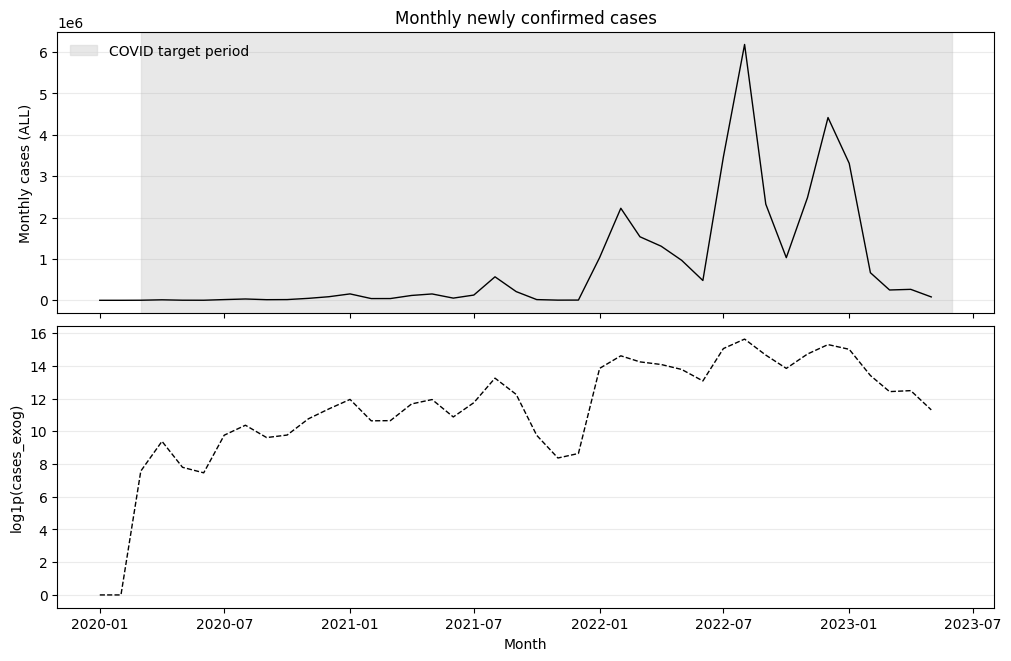

保存: C:\Users\fugat\Desktop\python_project\Transport_amount_project\output\covid_cases_exog\figures\monthly_cases_series.png


In [6]:
# 月次感染者数とlog1p系列を図示し、PNGにも保存
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, constrained_layout=True)
axes[0].plot(monthly['month_date'], monthly['monthly_cases_all'], color='black', linewidth=1.0)
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2023-05-31'), color='0.85', alpha=0.6, label='COVID target period')
axes[0].set_ylabel('Monthly cases (ALL)')
axes[0].set_title('Monthly newly confirmed cases')
axes[0].legend(loc='upper left', frameon=False)
axes[0].grid(True, axis='y', alpha=0.25)

axes[1].plot(monthly['month_date'], monthly['log1p_cases'], color='black', linewidth=1.0, linestyle='--')
axes[1].set_ylabel('log1p(cases_exog)')
axes[1].set_xlabel('Month')
axes[1].grid(True, axis='y', alpha=0.25)

FIG_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_PATH, dpi=200, bbox_inches='tight')
plt.show()
print(f'保存: {FIG_PATH}')

## 確認結果と次の判断

日次`ALL`と47都道府県列の合計は一致した。月次化では日次値を暦月合計し、対象期間外を0とした2種類の対数系列（同月・1か月ラグ）を保存した。

本ノートの出力は外生変数候補の確認用であり、ラグ0・ラグ1の採否や、2023年5月8日を含めるかどうかは、データ定義を確認したうえで後続の分析計画として決定する。